In [3]:
from pathlib import Path

DATA_TRAIN_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/generated_from_newdata")
image_paths = sorted(DATA_TRAIN_DIR.glob("*.png"))
labels_train = [ord(image_path.name[0].lower()) - ord("a") for image_path in image_paths]
print(labels_train)

DATA_TEST_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/validation_from_newdata")
image_paths = sorted(DATA_TEST_DIR.glob("*.png"))
labels_test = [ord(image_path.name[0].lower()) - ord("a") for image_path in image_paths]
print(labels_test)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 

In [4]:
from pathlib import Path

from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

image_count2 = len(list(DATA_TEST_DIR.glob('*.png')))
image_count = len(list(DATA_TRAIN_DIR.glob('*.png')))
print("Train images: " + str(image_count))
print("Test images: " + str(image_count2))

Train images: 1144
Test images: 26


Found 1144 files belonging to 26 classes.
Found 26 files belonging to 26 classes.
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]], shape=(256, 256, 1), dtype=float32)
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 ...

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]

 [[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [255.]]], shape=(256, 256, 1), dtype=float32)
tf.Tensor(
[[[255.]
  [255.]
  [255.]
  ...
  [255.]
  [255.]
  [2

I0000 00:00:1789830768.002097 1542371 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1789830768.002124 1542371 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


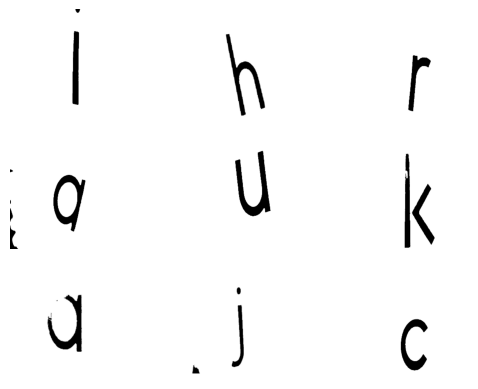

In [5]:
IMG_SIZE = (256, 256)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_TRAIN_DIR,
    labels=labels_train,
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_TEST_DIR,
    labels=labels_test,
    seed=SEED,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)

image_batch, label_batch = next(iter(train_ds))

import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        
        # 1. Grab the image tensor and drop the trailing channel dimension
        # This changes the shape from (30, 30, 1) to (30, 30)
        print(images[i])
        img = np.squeeze(images[i].numpy())
        
        # 2. Force Matplotlib to render it as grayscale using cmap='gray'
        # Also cast to uint8 to keep values correctly ranged 0-255
        plt.imshow(img, cmap="gray")
        
        plt.axis("off")
    plt.show()


In [ ]:
from pathlib import Path
import tensorflow as tf

PROCESSED_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/processed")
GENERATED_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/generated_from_newdata")
CAPTURED_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/real_capture_training")
VALIDATION_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/validation_from_newdata")

IMG_SIZE = (256, 256)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_paths = sorted(
    list(PROCESSED_DIR.glob("*.png"))
    + list(GENERATED_DIR.glob("*.png"))
    + list(CAPTURED_DIR.glob("*.png"))
)
validation_paths = sorted(VALIDATION_DIR.glob("*.png"))

def label_from_path(path):
    return ord(path.name[0].lower()) - ord("a")

def normalize_image(image):
    grayscale = image[:, :, 0]
    foreground = tf.where(grayscale < 128)

    def crop_foreground():
        minimum = tf.reduce_min(foreground, axis=0)
        maximum = tf.reduce_max(foreground, axis=0)
        min_y, min_x = tf.cast(minimum[0], tf.int32), tf.cast(minimum[1], tf.int32)
        max_y, max_x = tf.cast(maximum[0], tf.int32), tf.cast(maximum[1], tf.int32)
        foreground_height = max_y - min_y + 1
        foreground_width = max_x - min_x + 1
        padding = tf.cast(
            tf.round(tf.cast(tf.maximum(foreground_height, foreground_width), tf.float32) * 0.15),
            tf.int32,
        )
        crop_size = tf.maximum(foreground_height, foreground_width) + 2 * padding
        crop_size = tf.minimum(crop_size, tf.minimum(tf.shape(image)[0], tf.shape(image)[1]))
        center_y = (tf.cast(min_y, tf.float32) + tf.cast(max_y, tf.float32)) / 2
        center_x = (tf.cast(min_x, tf.float32) + tf.cast(max_x, tf.float32)) / 2
        top = tf.cast(tf.round(center_y - tf.cast(crop_size, tf.float32) / 2), tf.int32)
        left = tf.cast(tf.round(center_x - tf.cast(crop_size, tf.float32) / 2), tf.int32)
        top = tf.clip_by_value(top, 0, tf.shape(image)[0] - crop_size)
        left = tf.clip_by_value(left, 0, tf.shape(image)[1] - crop_size)
        cropped = tf.image.crop_to_bounding_box(image, top, left, crop_size, crop_size)

        crop_height = tf.shape(cropped)[0]
        crop_width = tf.shape(cropped)[1]
        scale = tf.minimum(
            tf.cast(IMG_SIZE[0], tf.float32) / tf.cast(crop_height, tf.float32),
            tf.cast(IMG_SIZE[1], tf.float32) / tf.cast(crop_width, tf.float32),
        )
        resized_height = tf.maximum(1, tf.cast(tf.round(tf.cast(crop_height, tf.float32) * scale), tf.int32))
        resized_width = tf.maximum(1, tf.cast(tf.round(tf.cast(crop_width, tf.float32) * scale), tf.int32))
        resized = tf.image.resize(cropped, [resized_height, resized_width])
        pad_top = (IMG_SIZE[0] - resized_height) // 2
        pad_left = (IMG_SIZE[1] - resized_width) // 2
        return tf.pad(
            resized,
            [
                [pad_top, IMG_SIZE[0] - resized_height - pad_top],
                [pad_left, IMG_SIZE[1] - resized_width - pad_left],
                [0, 0],
            ],
            constant_values=255.0,
        )

    return tf.cond(
        tf.shape(foreground)[0] > 0,
        crop_foreground,
        lambda: tf.image.resize(image, IMG_SIZE),
    )

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_png(image, channels=1)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = normalize_image(image)
    return image, label

def make_dataset(paths, shuffle):
    labels = [label_from_path(path) for path in paths]
    dataset = tf.data.Dataset.from_tensor_slices(
        ([str(path) for path in paths], labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            len(paths),
            seed=42,
            reshuffle_each_iteration=True,
        )

    return (
        dataset
        .map(load_image, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )

train_ds = make_dataset(train_paths, shuffle=True)
val_ds = make_dataset(validation_paths, shuffle=False)
diagnostic_ds = make_dataset(sorted(PROCESSED_DIR.glob("*.png")), shuffle=False)

class_names = list("abcdefghijklmnopqrstuvwxyz")
num_classes = len(class_names)

print(f"Training images: {len(train_paths)}")
print(f"Validation images: {len(validation_paths)}")
print(f"Captured training images: {len(list(CAPTURED_DIR.glob('*.png')))}")

Training images: 1925
Validation images: 26


In [107]:
# Extract the labelled glyphs from the log2 contact sheet.
from PIL import Image

LOG2_PATH = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/log2.png")
CAPTURED_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer/real_capture_training")
GRID_ROWS = 5
GRID_COLUMNS = 8

# Verify these labels against the original captures before training on them.
LOG2_LABELS = [
    ["g", "s", "s", "s", "r", "r", "r", "j"],
    ["b", "b", "b", "z", "g", "a", "a", "w"],
    ["w", "w", "w", "w", "w", "s", "s", "s"],
    ["f", "f", "f", "s", "s", "s", "x", "u"],
    ["w", "w", "w", "b", "b", "b", "b", "p"],
]

if len(LOG2_LABELS) != GRID_ROWS or any(
    len(row) != GRID_COLUMNS for row in LOG2_LABELS
):
    raise ValueError("LOG2_LABELS must contain one label per contact-sheet cell")

with Image.open(LOG2_PATH).convert("L") as sheet:
    cell_width = sheet.width / GRID_COLUMNS
    cell_height = sheet.height / GRID_ROWS
    CAPTURED_DIR.mkdir(exist_ok=True)

    for row in range(GRID_ROWS):
        for column in range(GRID_COLUMNS):
            left = round(column * cell_width) + 8
            top = round(row * cell_height) + 8
            right = round((column + 1) * cell_width) - 8
            bottom = round((row + 1) * cell_height) - 8
            label = LOG2_LABELS[row][column]
            output_path = CAPTURED_DIR / f"{label}_log2_r{row + 1}c{column + 1}.png"
            sheet.crop((left, top, right, bottom)).save(output_path)

print(f"Extracted {GRID_ROWS * GRID_COLUMNS} labelled captures to {CAPTURED_DIR}")
print("Review the crops and LOG2_LABELS before adding this directory to train_paths.")

Extracted 40 labelled captures to /Users/koensauren/Documents/luisterschelp/model_trainer/real_capture_training
Review the crops and LOG2_LABELS before adding this directory to train_paths.


Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 10s 145ms/step - accuracy: 0.1044 - loss: 3.7663 - val_accuracy: 0.0385 - val_loss: 3.2906 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.3652 - loss: 2.1215 - val_accuracy: 0.0385 - val_loss: 3.2729 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 136ms/step - accuracy: 0.6732 - loss: 1.1050 - val_accuracy: 0.0385 - val_loss: 3.0200 - learning_rate: 0.0010
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.8083 - loss: 0.6292 - val_accuracy: 0.3462 - val_loss: 2.0335 - learning_rate: 0.0010
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.8956 - loss: 0.3579 - val_accuracy: 0.7308 - val_loss: 1.4068 - learning_rate: 0.0010
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.9403 - loss: 0.2101 - val_accuracy: 0.8846 - val_loss: 0.7302 - learning_rate: 0.0010
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.9642 - loss: 0

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_12 (Sequential)      │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_13 (Sequential)      │ (None, 26)             │       193,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 579,104 (2.21 MB)

 Trainable params: 192,874 (753.41 KB)

...

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 256, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 256, 256, 16)   │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 256, 256, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 256, 256, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 32)   │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_17 (Activation)      │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_18 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_19 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,354 (755.29 KB)

 Trainable params: 192,874 (753.41 KB)

 Non-trainable params: 480 (1.88 KB)

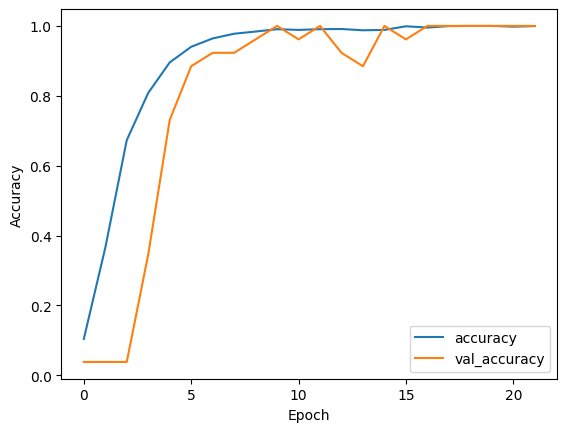

In [104]:
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

model_core = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(16, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(32, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 4, padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.GlobalMaxPooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

model_train = keras.Sequential([
    layers.Input(shape=(*IMG_SIZE, 1)),
    data_augmentation,
    model_core,
])

model_train.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True,
        mode="max",
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
    ),
]

history = model_train.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks
)

print("Classes:", class_names)
model_train.summary()
model_core.summary()

plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step
Processed diagnostic accuracy: 98.59%
Per-class diagnostic accuracy:
a: 100.00% (30 images)
b: 100.00% (30 images)
c: 100.00% (30 images)
d: 96.67% (30 images)
e: 100.00% (30 images)
f: 100.00% (30 images)
g: 100.00% (30 images)
h: 100.00% (30 images)
i: 100.00% (30 images)
j: 100.00% (30 images)
k: 100.00% (30 images)
l: 70.00% (30 images)
m: 96.77% (31 images)
n: 100.00% (30 images)
o: 100.00% (30 images)
p: 100.00% (30 images)
q: 100.00% (30 images)
r: 100.00% (30 images)
s: 100.00% (30 images)
t: 100.00% (30 images)
u: 100.00% (30 images)
v: 100.00% (30 images)
w: 100.00% (30 images)
x: 100.00% (30 images)
y: 100.00% (30 images)
z: 100.00% (30 images)


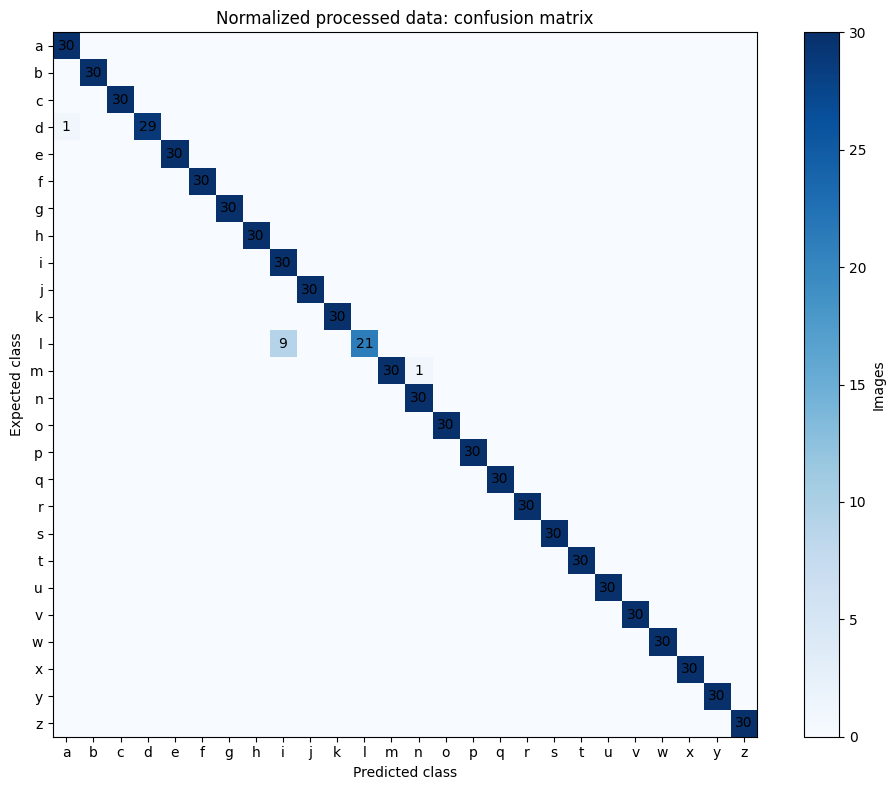

In [105]:
# Diagnostic evaluation on the normalized processed synthetic dataset.
diagnostic_class_names = list("abcdefghijklmnopqrstuvwxyz")
diagnostic_paths = sorted(PROCESSED_DIR.glob("*.png"))
diagnostic_labels = np.array([ord(path.name[0].lower()) - ord("a") for path in diagnostic_paths])

diagnostic_probabilities = model_core.predict(diagnostic_ds, verbose=1)
diagnostic_predictions = np.argmax(diagnostic_probabilities, axis=1)

diagnostic_accuracy = np.mean(diagnostic_predictions == diagnostic_labels)
print(f"Processed diagnostic accuracy: {diagnostic_accuracy:.2%}")

confusion = tf.math.confusion_matrix(
    diagnostic_labels,
    diagnostic_predictions,
    num_classes=len(diagnostic_class_names),
).numpy()

per_class_accuracy = np.divide(
    np.diag(confusion),
    confusion.sum(axis=1),
    out=np.zeros(len(diagnostic_class_names), dtype=float),
    where=confusion.sum(axis=1) != 0,
)

print("Per-class diagnostic accuracy:")
for class_name, accuracy, count in zip(
    diagnostic_class_names,
    per_class_accuracy,
    confusion.sum(axis=1),
):
    print(f"{class_name}: {accuracy:.2%} ({count} images)")

plt.figure(figsize=(10, 8))
plt.imshow(confusion, cmap="Blues")
plt.colorbar(label="Images")
plt.xticks(range(len(diagnostic_class_names)), diagnostic_class_names)
plt.yticks(range(len(diagnostic_class_names)), diagnostic_class_names)
plt.xlabel("Predicted class")
plt.ylabel("Expected class")
plt.title("Normalized processed data: confusion matrix")

for row in range(len(diagnostic_class_names)):
    for column in range(len(diagnostic_class_names)):
        if confusion[row, column] > 0:
            plt.text(column, row, confusion[row, column], ha="center", va="center")

plt.tight_layout()
plt.show()

[[3.2812547e-08 1.2484628e-07 7.2946065e-13 7.8818349e-12 1.2839262e-12
  3.1504758e-08 7.4779660e-14 2.0172106e-06 1.9129058e-12 2.3647821e-09
  9.9968088e-01 4.2167107e-12 2.4132500e-09 2.5865551e-10 5.2504860e-19
  1.5818910e-12 1.4897699e-08 1.2895822e-10 1.7085205e-13 5.7464673e-09
  1.0699381e-09 7.2915833e-07 1.3828484e-04 1.7780934e-04 1.9294254e-11
  1.2739548e-07]]


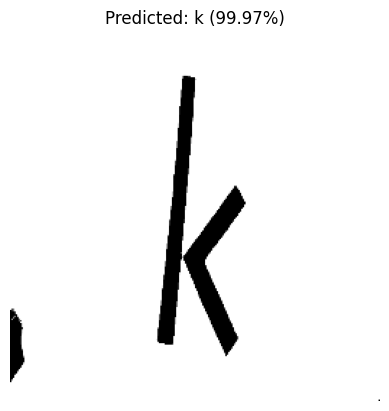

File: k5.png
Predicted class: k
Confidence: 99.97%


In [94]:
import random

image_path = random.choice(list(DATA_TEST_DIR.glob("*.png")))

image = tf.keras.utils.load_img(
    image_path,
    color_mode="grayscale",
    target_size=IMG_SIZE,
)
image_array = tf.keras.utils.img_to_array(image)
image_batch = tf.expand_dims(image_array, axis=0)

predictions = model_core.predict(image_batch, verbose=0)
print(predictions)
predicted_index = int(np.argmax(predictions[0]))
alphabet = ["a","b","c","d","e","f","g","h","i","j","k","l","m","n","o","p","q","r","s","t","u","v","w","x","y","z"]

predicted_class = alphabet[predicted_index]
confidence = float(predictions[0][predicted_index])


plt.imshow(np.squeeze(image_array), cmap="gray")
plt.axis("off")
plt.title(f"Predicted: {predicted_class} ({confidence:.2%})")
plt.show()

print(f"File: {image_path.name}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.2%}")

Raw validation accuracy: 96.15%
Browser-style thresholded accuracy: 92.31%


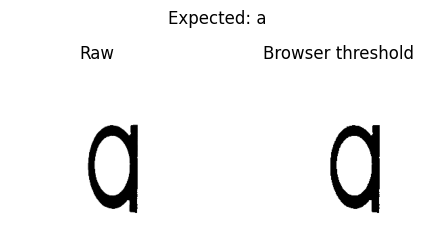

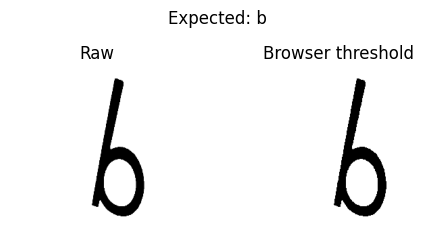

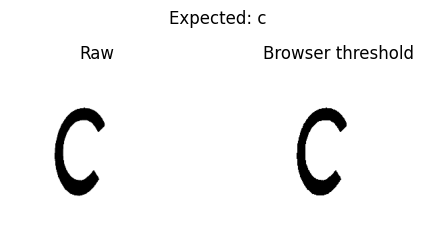

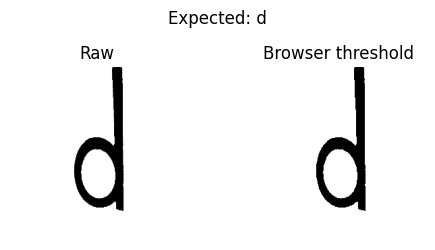

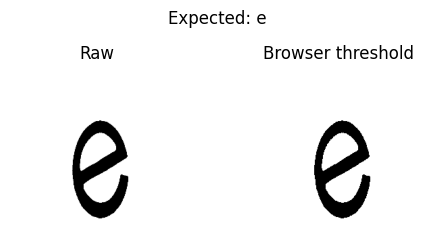

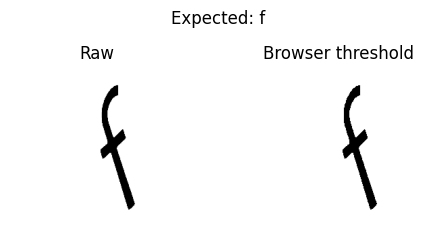

In [98]:
# Compare the model's normal validation input with browser-style thresholded input.
def otsu_threshold_image(image):
    image = np.asarray(image, dtype=np.uint8)
    histogram = np.bincount(image.ravel(), minlength=256)
    total = image.size
    intensity_sum = np.dot(np.arange(256), histogram)
    background_weight = 0
    background_sum = 0
    best_variance = -1
    best_threshold = 0

    for threshold in range(256):
        background_weight += histogram[threshold]
        if background_weight == 0:
            continue
        foreground_weight = total - background_weight
        if foreground_weight == 0:
            break
        background_sum += threshold * histogram[threshold]
        background_mean = background_sum / background_weight
        foreground_mean = (intensity_sum - background_sum) / foreground_weight
        variance = (
            background_weight
            * foreground_weight
            * (background_mean - foreground_mean) ** 2
        )
        if variance > best_variance:
            best_variance = variance
            best_threshold = threshold

    return np.where(image >= best_threshold, 255.0, 0.0).astype(np.float32)

validation_images, validation_labels = next(iter(val_ds.unbatch().batch(len(validation_paths))))
validation_images = validation_images.numpy()
validation_labels = validation_labels.numpy()
thresholded_images = np.stack([
    otsu_threshold_image(image[:, :, 0])[:, :, None]
    for image in validation_images
])

raw_output = model_core.predict(validation_images, verbose=0)
thresholded_output = model_core.predict(thresholded_images, verbose=0)
raw_predictions = np.argmax(raw_output, axis=1)
thresholded_predictions = np.argmax(thresholded_output, axis=1)

raw_accuracy = np.mean(raw_predictions == validation_labels)
thresholded_accuracy = np.mean(thresholded_predictions == validation_labels)
print(f"Raw validation accuracy: {raw_accuracy:.2%}")
print(f"Browser-style thresholded accuracy: {thresholded_accuracy:.2%}")

for index in range(min(6, len(validation_images))):
    figure, axes = plt.subplots(1, 2, figsize=(5, 2.5))
    axes[0].imshow(validation_images[index, :, :, 0], cmap="gray", vmin=0, vmax=255)
    axes[0].set_title("Raw")
    axes[1].imshow(thresholded_images[index, :, :, 0], cmap="gray", vmin=0, vmax=255)
    axes[1].set_title("Browser threshold")
    for axis in axes:
        axis.axis("off")
    figure.suptitle(f"Expected: {class_names[int(validation_labels[index])]}")
    plt.tight_layout()
    plt.show()

In [106]:
# Export the exact inference model used for parity-checked browser inference.
import shutil
import sys
from types import ModuleType

MODEL_DIR = Path("/Users/koensauren/Documents/luisterschelp/model_trainer")
SAVED_MODEL_DIR = MODEL_DIR / "browser_saved_model"
BROWSER_MODEL_DIR = MODEL_DIR / "browser_model"
TFLITE_PATH = MODEL_DIR / "browser_model.tflite"

for output_path in (SAVED_MODEL_DIR, BROWSER_MODEL_DIR):
    if output_path.exists():
        shutil.rmtree(output_path)
if TFLITE_PATH.exists():
    TFLITE_PATH.unlink()

# Export model_core, not model_train: random augmentation must never be in inference.
model_core.export(
    SAVED_MODEL_DIR,
    input_signature=[
        tf.TensorSpec([None, IMG_SIZE[0], IMG_SIZE[1], 1], tf.float32),
    ],
)

# tensorflowjs imports this optional package even for ordinary TensorFlow models.
# The model has no TensorFlow Decision Forests operators.
sys.modules.setdefault(
    "tensorflow_decision_forests",
    ModuleType("tensorflow_decision_forests"),
)
import tensorflowjs as tfjs

tfjs.converters.convert_tf_saved_model(
    str(SAVED_MODEL_DIR),
    str(BROWSER_MODEL_DIR),
    signature_def="serving_default",
)

# Convert the same SavedModel to TFLite and compare it against Keras.
converter = tf.lite.TFLiteConverter.from_saved_model(str(SAVED_MODEL_DIR))
tflite_bytes = converter.convert()
TFLITE_PATH.write_bytes(tflite_bytes)

interpreter = tf.lite.Interpreter(model_path=str(TFLITE_PATH))
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

sample_images, _ = next(iter(val_ds))
keras_output = model_core(sample_images, training=False).numpy()
input_data = sample_images.numpy().astype(input_details["dtype"])
interpreter.resize_tensor_input(
    input_details["index"],
    input_data.shape,
    strict=False,
)
interpreter.allocate_tensors()
interpreter.set_tensor(input_details["index"], input_data)
interpreter.invoke()
tflite_output = interpreter.get_tensor(output_details["index"])

max_difference = float(np.max(np.abs(keras_output - tflite_output)))
keras_predictions = np.argmax(keras_output, axis=1)
tflite_predictions = np.argmax(tflite_output, axis=1)

print(f"TF.js model: {BROWSER_MODEL_DIR / 'model.json'}")
print(f"TFLite model: {TFLITE_PATH}")
print(f"Input shape: {input_details['shape'].tolist()}")
print(f"Input dtype: {input_details['dtype'].__name__}")
print(f"Keras/TFLite maximum output difference: {max_difference:.6g}")
print(f"Keras/TFLite predicted classes identical: {np.array_equal(keras_predictions, tflite_predictions)}")

if max_difference > 1e-5 or not np.array_equal(keras_predictions, tflite_predictions):
    raise RuntimeError("Export parity check failed")

print("Export parity check passed.")

INFO:tensorflow:Assets written to: /Users/koensauren/Documents/luisterschelp/model_trainer/browser_saved_model/assets


INFO:tensorflow:Assets written to: /Users/koensauren/Documents/luisterschelp/model_trainer/browser_saved_model/assets


Saved artifact at '/Users/koensauren/Documents/luisterschelp/model_trainer/browser_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 1), dtype=tf.float32, name=None)
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  5443971632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5443967584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466378256: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466374560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466390224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466381072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466376672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466376496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466385648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466384592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  5466384240: Te

I0000 00:00:1789833957.271981 1542371 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1789833957.272043 1542371 single_machine.cc:374] Starting new session
I0000 00:00:1789833957.272159 1542371 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1789833957.272166 1542371 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
W0000 00:00:1789833957.601990 1542371 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1789833957.602002 1542371 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
/Users/koensauren/Documents/luisterschelp/luisterschelp/lib/python3.10/site-packages/tensorflow/li

TF.js model: /Users/koensauren/Documents/luisterschelp/model_trainer/browser_model/model.json
TFLite model: /Users/koensauren/Documents/luisterschelp/model_trainer/browser_model.tflite
Input shape: [1, 256, 256, 1]
Input dtype: float32
Keras/TFLite maximum output difference: 2.26498e-06
Keras/TFLite predicted classes identical: True
Export parity check passed.
